In [38]:
import os
import json
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, AIMessage, SystemMessage, ToolMessage
# from utilities import get_llm
from utilities import get_llm
from config import settings
from pydantic import BaseModel

import httpx
from langchain_core.tools import tool
import openmeteo_requests
from typing import Annotated, List, Optional
from langgraph.graph import StateGraph, END, START
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
import operator

from typing_extensions import TypedDict
from pydantic import BaseModel, Field, field_validator
from datetime import date

from tavily import TavilyClient
from langchain_community.tools.tavily_search import TavilySearchResults

# Data Model

In [39]:
class DayWeatherInfo(BaseModel):
    location: str = Field(..., examples=["Chicago"])
    date: str = Field(..., examples=["2026-06-20"])
    temp_min_c: Optional[float] = None
    temp_max_c: Optional[float] = None
    precipitation_mm: Optional[float] = None
    condition: Optional[str] = None
    error: Optional[str] = None

class AttractionInfo(BaseModel):
    name: str
    attraction_type: str
    description: str
    latitude: Optional[float] = None
    longitude: Optional[float] = None
    booking_required: Optional[bool] = None
    estimated_fee_usd: Optional[float] = None
    fee_notes: Optional[str] = None

class AttractionsList(BaseModel):
    attractions: list[AttractionInfo]

class HotelOffer(BaseModel):
    ota: str        # e.g. "Hotels.com"
    price_usd: float

class HotelInfo(BaseModel):
    name: str
    hotel_key: str
    rating: Optional[float] = None
    address: Optional[str] = None
    offers: list[HotelOffer] = Field(default_factory=list)

## Reducer functions ##
def merge_attractions(
    existing: list[AttractionInfo],
    incoming: list[AttractionInfo],
) -> list[AttractionInfo]:
    by_name = {a.name: a for a in existing}
    for a in incoming:
        by_name[a.name] = a
    return list(by_name.values())


class TripPlannerState(TypedDict):
    messages: Annotated[list, add_messages]
    weather_info: Annotated[list[DayWeatherInfo], operator.add]
    attractions: Annotated[list[AttractionInfo], merge_attractions]
    hotels: Annotated[list[HotelInfo], operator.add]


# Build Agents
## Weather Agent

In [40]:
import requests
from datetime import datetime

@tool
def get_weather_forecast(city: str, start_date: str, end_date: str) -> dict:
    """
    Get a daily weather forecast for a city between two dates.

    Args:
        city: City name, e.g. "Tokyo" or "New York"
        start_date: "YYYY-MM-DD"
        end_date: "YYYY-MM-DD"

    Returns:
        dict with city info and a list of daily forecasts.
    """
    # validate dates
    try:
        d1 = datetime.strptime(start_date, "%Y-%m-%d")
        d2 = datetime.strptime(end_date, "%Y-%m-%d")
    except ValueError:
        raise ValueError("Dates must be in YYYY-MM-DD format")
    if d2 < d1:
        raise ValueError("end_date must not be before start_date")

    # step 1: geocode city name -> lat/lon
    geo_resp = requests.get(
        "https://geocoding-api.open-meteo.com/v1/search",
        params={"name": city, "count": 1},
        timeout=10,
    )
    geo_resp.raise_for_status()
    geo_data = geo_resp.json()

    if not geo_data.get("results"):
        raise ValueError(f"Could not find location: {city}")

    place = geo_data["results"][0]
    lat, lon = place["latitude"], place["longitude"]
    resolved_name = place.get("name", city)

    # step 2: fetch forecast for date range
    forecast_resp = requests.get(
        "https://api.open-meteo.com/v1/forecast",
        params={
            "latitude": lat,
            "longitude": lon,
            "start_date": start_date,
            "end_date": end_date,
            "daily": "temperature_2m_max,temperature_2m_min,precipitation_sum,weathercode",
            "timezone": "auto",
        },
        timeout=10,
    )
    forecast_resp.raise_for_status()
    daily = forecast_resp.json().get("daily", {})

    if not daily:
        raise ValueError("No forecast data returned for the given dates")

    forecast = []
    for i, date in enumerate(daily["time"]):
        forecast.append({
            "date": date,
            "temp_max_c": daily["temperature_2m_max"][i],
            "temp_min_c": daily["temperature_2m_min"][i],
            "precipitation_mm": daily["precipitation_sum"][i],
            "condition": _weathercode_to_text(daily["weathercode"][i]),
        })

    return {"city": resolved_name, "latitude": lat, "longitude": lon, "forecast": forecast}


def _weathercode_to_text(code: int) -> str:
    mapping = {
        0: "Clear sky", 1: "Mainly clear", 2: "Partly cloudy", 3: "Overcast",
        45: "Fog", 48: "Depositing rime fog",
        51: "Light drizzle", 53: "Moderate drizzle", 55: "Dense drizzle",
        61: "Slight rain", 63: "Moderate rain", 65: "Heavy rain",
        71: "Slight snow", 73: "Moderate snow", 75: "Heavy snow",
        80: "Slight rain showers", 81: "Moderate rain showers", 82: "Violent rain showers",
        95: "Thunderstorm", 96: "Thunderstorm with hail", 99: "Thunderstorm with heavy hail",
    }
    return mapping.get(code, f"Unknown ({code})")

In [41]:
WEATHER_AGENT_SYSTEM_PROMPT = """You are a helpful assistant for providing weather forecasts in
a larger trip planning application.
The user would describe a travel plan, and your task is to look through the conversation history 
and identify the destination(s) and the respective date(s) to query the weather forecast for 
those locations.
If the weather information is unavailable, stop any tool calling and inform the user as it is.

** Important **
You must use the get_weather tool to search for weather forecast information. 
Do not come out with weather information on your own.

** Output **
Present any weather information found with short, succinct descriptive text. Do not return anything else.
"""


In [42]:
llm = get_llm()
tools = [get_weather_forecast]
llm_w_tools = llm.bind_tools(tools)


In [43]:
async def weather_agent(state: TripPlannerState):
    """The main researcher agent."""
    response = await llm_w_tools.ainvoke([
        SystemMessage(content=WEATHER_AGENT_SYSTEM_PROMPT)
        ] + state['messages'])
    return {"messages": [response]}

def weather_router(state: TripPlannerState) -> str:
    """Route to the tools node if the researcher makes a tool call."""
    if state['messages'][-1].tool_calls:
        return "tools"
    return END

In [44]:
async def parse_weather_results(state: TripPlannerState) -> dict:
    last_message = state["messages"][-1]  # ToolMessage placed by ToolNode

    # ToolNode serialises successful tool output as JSON; exceptions become plain strings
    try:
        tool_result = json.loads(last_message.content)
    except (json.JSONDecodeError, TypeError):
        # Tool raised an exception (e.g. city not found, API error)
        return {"weather_info": [DayWeatherInfo(
            location="Unknown",
            date="Unknown",
            error=last_message.content,
        )]}

    location = tool_result["city"]
    day_weather_list = [
        DayWeatherInfo(
            location=location,
            date=entry["date"],
            temp_min_c=entry["temp_min_c"],
            temp_max_c=entry["temp_max_c"],
            precipitation_mm=entry["precipitation_mm"],
            condition=entry["condition"],
        )
        for entry in tool_result["forecast"]
    ]
    return {"weather_info": day_weather_list}

## Attraction Agent
Search for tourist attractions after gathered weather information.

Weather forecast may or may not be available, agent only need to consider weather
if it is available.

Later stage would integrate with user long term preferences.

In [45]:
ATTRACTION_AGENT_SYSTEM_PROMPT="""
You are a helpful assistant specialized at recommending tourist attractions
based on user requirement or past preferences.
Your responsibility is to look through the message list, identify where the
user is traveling to and the respective dates, the generate customized search
terms to search for tourist attractions that best matches user requirement.
You may see messages regarding weather information present in the message 
history. If they are present, you may consider generate 1 search term based
on weather condition.


** Important **
Do not fabricate any tourist attractions. Always use the search_attraction tool
to search for attraction information.

** Output **
If attraction search is successful, the information you provided would be passed 
down to the next agent, so you don't need to output anything.

"""

In [46]:
tavily_client = TavilyClient(api_key=settings.tavily_api_key)

@tool
async def search_attraction(search_query: str):
    """
    Search with tavily client with the custom search query, and return maximum 5 results

    Args:
        search_query: terms to search with tavily client.

    Returns:
        dict with search query, answer and a list of search results.
    """
    try:
        response = tavily_client.search(
            query=search_query, search_depth="basic", max_results=5, include_answer=True
        )
        return response
    except Exception as e:
        print(f"❌ Error searching {search_query} with Tavily: {e}")
        return None



In [47]:
# search_term = "Museums in Chicago"

# test_result = await search_attraction(search_term)
# test_result

In [48]:
# tavily = TavilySearchResults(max_results=5)

llm_w_tavily = get_llm().bind_tools([search_attraction])

extractor = get_llm().with_structured_output(AttractionsList)

In [49]:
async def attraction_agent(state: TripPlannerState) -> dict:
    response = await llm_w_tavily.ainvoke([
        SystemMessage(content=ATTRACTION_AGENT_SYSTEM_PROMPT),
        *state["messages"],
    ])
    return {"messages": [response]}

def _chunk_text(text: str, chunk_size: int = 800, overlap: int = 100) -> list[str]:
    chunks = []
    start = 0
    while start < len(text):
        chunks.append(text[start : start + chunk_size])
        start += chunk_size - overlap
    return chunks


async def extract_attractions(state: TripPlannerState) -> dict:
    tool_messages = [m for m in state["messages"] if isinstance(m, ToolMessage)]
    tool_result = json.loads(tool_messages[-1].content)

    all_attractions: list[AttractionInfo] = []
    seen: set[str] = set()

    for result in tool_result["results"]:
        content = f"Title: {result['title']}\n\nContent: {result['content']}"

        for chunk in _chunk_text(content, chunk_size=800, overlap=100):
            extracted = await extractor.ainvoke([
                SystemMessage("Extract tourist attractions from the search result below. "
                              "Only include attractions explicitly mentioned. "
                              "Set fields to null if not mentioned. Be concise."),
                HumanMessage(content=chunk),
            ])
            for attraction in extracted.attractions:
                key = attraction.name.lower()
                if key not in seen:
                    seen.add(key)
                    all_attractions.append(attraction)

    return {"attractions": all_attractions}




def attraction_router(state: TripPlannerState) -> str:
    if state["messages"][-1].tool_calls:
        return "tools"
    return END

async def geocode_attractions(state: TripPlannerState) -> dict:
    geocoded = []
    async with httpx.AsyncClient() as client:
        for attraction in state["attractions"]:
            geo = await client.get(
                "https://maps.googleapis.com/maps/api/geocode/json",
                params={"address": attraction.name, "key": settings.google_maps_api_key},
            )
            geo_data = geo.json()
            if geo_data.get("results"):
                location = geo_data["results"][0]["geometry"]["location"]
                geocoded.append(attraction.model_copy(update={
                    "latitude": location["lat"],
                    "longitude": location["lng"],
                }))
            else:
                geocoded.append(attraction)  # keep lat/lon as None

    return {"attractions": geocoded}


In [50]:
# async with httpx.AsyncClient() as client:
#     result = await client.get(
#         "https://maps.googleapis.com/maps/api/geocode/json",
#         params={"address": "New York Empire State Building", "key": settings.google_maps_api_key},
#     )
#     print(result.json())
    

In [51]:
# location = result.json()["results"][0]["geometry"]["location"]
# location

## Hotel Agent


In [52]:
@tool
async def search_hotels(
    city: str,
    chk_in: str,
    chk_out: str,
    adults: int = 1,
    limit: int = 5,
    sort: str = "best_value",
) -> dict:
    """
    Search for available hotels in a city for given dates using the Xotelo API.

    Args:
        city: City name, e.g. "Tokyo"
        chk_in: Check-in date "YYYY-MM-DD"
        chk_out: Check-out date "YYYY-MM-DD"
        adults: Number of adults (default 1)
        limit: Number of hotels to return (default 5)
        sort: Sort order for /api/list — "best_value", "popularity", or "distance" (default "best_value")

    Returns:
        dict with city, dates, and a list of hotels with rates from multiple OTAs.
    """
    BASE = "https://xotelo-hotel-prices.p.rapidapi.com"
    headers = {
        "X-RapidAPI-Key": settings.rapidapi_key,
        "X-RapidAPI-Host": "xotelo-hotel-prices.p.rapidapi.com",
    }

    async with httpx.AsyncClient(timeout=15, headers=headers) as client:
        # Step 1: search hotels by city name directly (accommodation search returns hotel_key per item)
        r = await client.get(f"{BASE}/api/search", params={"query": city, "location_type": "accommodation"})
        r.raise_for_status()
        data = r.json()
        search_list = (data.get("result") or {}).get("list", [])

        if not search_list:
            # Fallback: try /api/list with a geo search for location_key
            r2 = await client.get(f"{BASE}/api/search", params={"query": city, "location_type": "geo"})
            r2.raise_for_status()
            geo_list = (r2.json().get("result") or {}).get("list", [])
            if not geo_list:
                return {"error": f"Location not found: {city}", "hotels": []}
            location_key = geo_list[0]["location_key"]
            r3 = await client.get(f"{BASE}/api/list", params={"location_key": location_key, "limit": limit, "sort": sort})
            r3.raise_for_status()
            search_list = (r3.json().get("result") or {}).get("list", [])

        # Step 2: fetch rates for each hotel
        hotels = []
        for h in search_list[:limit]:
            hotel_key = h.get("hotel_key") or h.get("key")
            if not hotel_key:
                continue

            r = await client.get(f"{BASE}/api/rates", params={
                "hotel_key": hotel_key,
                "chk_in": chk_in,
                "chk_out": chk_out,
                "adults": adults,
            })
            r.raise_for_status()
            rates = (r.json().get("result") or {}).get("rates", [])

            hotels.append({
                "name": h.get("name"),
                "hotel_key": hotel_key,
                "rating": h.get("rating"),
                "address": h.get("address"),
                "offers": [{"ota": rate.get("name"), "price_usd": rate.get("rate")} for rate in rates],
            })

    return {"city": city, "chk_in": chk_in, "chk_out": chk_out, "hotels": hotels}


In [53]:
# Debug: test accommodation search and inspect hotel result structure
headers = {
    "X-RapidAPI-Key": settings.rapidapi_key,
    "X-RapidAPI-Host": "xotelo-hotel-prices.p.rapidapi.com",
}
BASE = "https://xotelo-hotel-prices.p.rapidapi.com"

async with httpx.AsyncClient(timeout=15, headers=headers) as client:
    r = await client.get(f"{BASE}/api/search", params={"query": "Chicago", "location_type": "accommodation"})
    print(f"status: {r.status_code}")
    data = r.json()
    print(f"error:  {data.get('error')}")
    items = (data.get("result") or {}).get("list", [])
    print(f"count:  {len(items)}")
    if items:
        print(f"\nfirst item keys: {list(items[0].keys())}")
        print(f"first item: {items[0]}")


status: 200
error:  None
count:  10

first item keys: ['hotel_key', 'location_key', 'name', 'location_id', 'parent_id', 'place_name', 'short_place_name', 'street_address', 'place_type', 'latitude', 'longitude', 'country', 'url', 'image']
first item: {'hotel_key': 'g35805-d9145578', 'location_key': 'g35805', 'name': 'LondonHouse Chicago, Curio Collection by Hilton', 'location_id': 9145578, 'parent_id': 35805, 'place_name': 'Chicago, Illinois', 'short_place_name': 'Illinois, United States', 'street_address': '85 E Wacker Drive', 'place_type': 'ACCOMMODATION', 'latitude': 41.887833, 'longitude': -87.625427, 'country': 'Illinois', 'url': 'https://www.tripadvisor.com/Hotel_Review-g35805-d9145578-Reviews-LondonHouse_Chicago_Curio_Collection_by_Hilton-Chicago_Illinois.html', 'image': 'https://dynamic-media-cdn.tripadvisor.com/media/photo-o/30/b5/a2/40/restaurant.jpg'}


In [54]:
HOTEL_AGENT_SYSTEM_PROMPT = """You are a helpful assistant specialized in finding hotel options for travelers.
Look through the conversation history to identify the destination city and travel dates (check-in and check-out),
then use the search_hotels tool to retrieve available options with prices.

You may choose the sort order based on user preference:
- "best_value" — default, balance of price and rating
- "popularity" — most booked hotels first
- "distance" — closest to city center first

** Important **
- Always use the search_hotels tool. Do not fabricate hotel information.
- Check the global state to see if there is already comprehensive hotel information. If there is, present the hotel
information and end the search loop.
- If information search is successful, these information would be pass down to the next agent,
which would organize information into a proper itinerary. You don't need to output anything.

"""

hotel_tools = [search_hotels]
llm_w_hotel_tools = get_llm().bind_tools(hotel_tools)


In [55]:
async def hotel_agent(state: TripPlannerState) -> dict:
    response = await llm_w_hotel_tools.ainvoke([
        SystemMessage(content=HOTEL_AGENT_SYSTEM_PROMPT),
        *state["messages"],
    ])
    return {"messages": [response]}


def hotel_router(state: TripPlannerState) -> str:
    if state["messages"][-1].tool_calls:
        return "tools"
    return END


async def parse_hotel_results(state: TripPlannerState) -> dict:
    last = state["messages"][-1]
    try:
        tool_result = json.loads(last.content)
    except (json.JSONDecodeError, TypeError):
        return {"hotels": []}

    if tool_result.get("error"):
        return {"hotels": []}

    hotels = [
        HotelInfo(
            name=h["name"],
            hotel_key=h["hotel_key"],
            rating=h.get("rating"),
            address=h.get("address"),
            offers=[HotelOffer(**o) for o in h.get("offers", [])],
        )
        for h in tool_result.get("hotels", [])
        if h.get("name") and h.get("hotel_key")
    ]
    return {"hotels": hotels}


## Itinerary Agent

In [56]:
ITINERARY_AGENT_SYSTEM_PROMPT="""
You are an expert specialized at trip planning. Your role is to help the user 
plan a trip, based on gathered information. 
You are provided with user query, searched results on destination weather, 
tourist attractions, and hotel options. Your role is to look through the 
weather_info, attractions and hotels in the global state, and then plan a trip 
itinerary based on these gathered information. 

** Important **
- Do not come up with any other new information, strictly used information
provided earlier on
- Use the default planning preferences unless the user stated otherwise in
their preferences

## Default Planning Preferences 
- Consider weather conditions when selecting attractions. E.g. Prefer indoor
activities on a rainy day
- Attractions closer together should be planned on the same day to save travel
time
- Choose more popular and iconic attractions unless the user stated otherwise
- Choose hotel that are more convenient to stay and travel
"""

itinerary_llm = get_llm()

In [57]:
async def itinerary_agent(state: TripPlannerState) -> dict:
    response = await itinerary_llm.ainvoke([
        SystemMessage(content=ITINERARY_AGENT_SYSTEM_PROMPT),
        *state["messages"],
    ])
    return {"messages": [response]}

# Graph

## Weather Graph

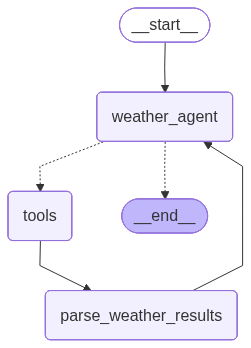

In [58]:
weather_builder = StateGraph(TripPlannerState)

weather_builder.add_node(weather_agent)
weather_builder.add_node("tools", ToolNode(tools))
weather_builder.add_node(parse_weather_results)

weather_builder.set_entry_point("weather_agent")
weather_builder.add_edge("tools", "parse_weather_results")       # parse tool output into weather_info
weather_builder.add_edge("parse_weather_results", "weather_agent")  # then back to LLM
weather_builder.add_conditional_edges(
    "weather_agent",
    weather_router,
    {"tools": "tools", END: END},
)

weather_graph = weather_builder.compile()

from IPython.display import Image
Image(weather_graph.get_graph().draw_mermaid_png())

## Attraction Graph

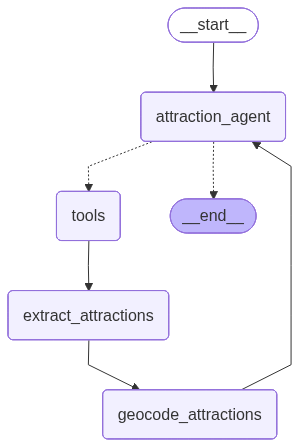

In [59]:
attraction_builder = StateGraph(TripPlannerState)
attraction_builder.add_node(attraction_agent)
attraction_builder.add_node("tools", ToolNode([search_attraction]))
attraction_builder.add_node(extract_attractions)
attraction_builder.add_node(geocode_attractions)

attraction_builder.set_entry_point("attraction_agent")
attraction_builder.add_conditional_edges("attraction_agent", attraction_router, {"tools": "tools", END: END})
attraction_builder.add_edge("tools", "extract_attractions")
attraction_builder.add_edge("extract_attractions", "geocode_attractions")
attraction_builder.add_edge("geocode_attractions", "attraction_agent")

attraction_graph = attraction_builder.compile()

from IPython.display import Image
Image(attraction_graph.get_graph().draw_mermaid_png())

## Hotel Graph

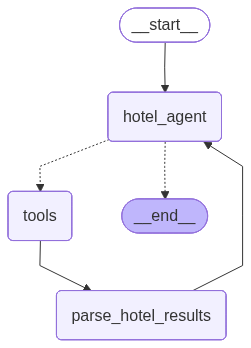

In [60]:
hotel_builder = StateGraph(TripPlannerState)
hotel_builder.add_node(hotel_agent)
hotel_builder.add_node("tools", ToolNode([search_hotels]))
hotel_builder.add_node(parse_hotel_results)

hotel_builder.set_entry_point("hotel_agent")
hotel_builder.add_conditional_edges("hotel_agent", hotel_router, {"tools": "tools", END: END})
hotel_builder.add_edge("tools", "parse_hotel_results")
hotel_builder.add_edge("parse_hotel_results", "hotel_agent")

hotel_graph = hotel_builder.compile()

from IPython.display import Image
Image(hotel_graph.get_graph().draw_mermaid_png())

## Sequential Graph

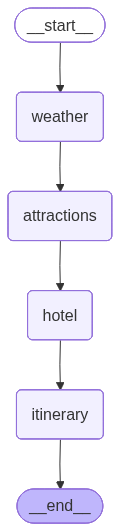

In [61]:
sequential_builder = StateGraph(TripPlannerState)

sequential_builder.add_node("weather", weather_graph)
sequential_builder.add_node("attractions", attraction_graph)
sequential_builder.add_node("hotel", hotel_graph)
sequential_builder.add_node("itinerary", itinerary_agent)

sequential_builder.set_entry_point("weather")

sequential_builder.add_edge("weather", "attractions")
sequential_builder.add_edge("attractions", "hotel")
sequential_builder.add_edge("hotel", "itinerary")
sequential_builder.add_edge("itinerary", END)

sequential_graph = sequential_builder.compile()

Image(sequential_graph.get_graph().draw_mermaid_png())

# Graph Test

In [62]:
trial_state = TripPlannerState(
    messages=HumanMessage(content="I'm traveling to Chicago from 25 June to 26 June, 2026. Help me plan my trip.")
)

In [ ]:
result = await graph.ainvoke(
    input=trial_state
)

result

## Test with streaming events and Final state

In [63]:
final_state = None

async for event in sequential_graph.astream_events(input=trial_state, version="v2"):
    kind = event["event"]
    name = event.get("name", "")

    # capture final state when the graph completes
    if kind == "on_chain_end" and name == "LangGraph":
        final_state = event["data"]["output"]

    elif kind == "on_chain_start" and name in ("attraction_agent", "extract_attractions", "geocode_attractions"):
        print(f"\n>>> Starting {name}...")

    elif kind == "on_chat_model_stream":
        token = event["data"]["chunk"].content
        if isinstance(token, str):
            print(token, end="", flush=True)

    elif kind == "on_tool_start":
        print(f"\n[Tool call: {name} with args {event['data'].get('input')}]")

    elif kind == "on_tool_end":
        print(f"\n[Tool result: {name} done]")

# inspect after the loop
print("\n\n=== Final State ===")
print("Attractions:")
for a in final_state["attractions"]:
    print(f"  {a}")



[Tool call: get_weather_forecast with args {'end_date': '2026-06-26', 'start_date': '2026-06-25', 'city': 'Chicago'}]

[Tool result: get_weather_forecast done]
On June 25, Chicago will have light drizzle with a high of 25.9°C and a low of 17.2°C. On June 26, it will be overcast with a high of 20.1°C and a low of 15.7°C.
>>> Starting attraction_agent...


=== Final State ===
Attractions:


In [64]:
final_state

{'messages': [HumanMessage(content="I'm traveling to Chicago from 25 June to 26 June, 2026. Help me plan my trip.", additional_kwargs={}, response_metadata={}, id='62173668-1167-496d-a25d-6188d00eff42'),
  AIMessage(content=[{'type': 'thinking', 'thinking': 'The user is asking for help planning a trip to Chicago from June 25th to June 26th, 2026.\nThe user\'s request implies they want to know the weather for these dates to help with their planning.\nI should use the `get_weather_forecast` tool to get the weather for Chicago for the specified dates.\n\nPlan:\n1. Identify the city: Chicago.\n2. Identify the start date: 2026-06-25.\n3. Identify the end date: 2026-06-26.\n4. Call `get_weather_forecast(city="Chicago", start_date="2026-06-25", end_date="2026-06-26")`.', 'index': 0}], additional_kwargs={'function_call': {'name': 'get_weather_forecast', 'arguments': '{"end_date": "2026-06-26", "start_date": "2026-06-25", "city": "Chicago"}'}, '__gemini_function_call_thought_signatures__': {'q5